# Vietnamese Online News Dataset — Text Feature Extraction

**Yêu cầu:** *Apply 4 techniques on a given dataset.*

Notebook áp dụng bốn kỹ thuật trích xuất đặc trưng văn bản: **Bag of Words, Word N-grams, TF-IDF và Feature Hashing**. Dữ liệu được tiền xử lý ngắn gọn theo cùng quy trình của tuần 1 trước khi vector hóa.

## 1. Load Dataset

Đọc bộ dữ liệu Vietnamese Online News từ Kaggle và chỉ sử dụng cột `content`.

In [1]:
%pip install -q underthesea

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.3/7.3 MB 19.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 47.9 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [2]:
import re
import html
import unicodedata

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from underthesea import word_tokenize
from sklearn.feature_extraction.text import (
    CountVectorizer,
    TfidfVectorizer,
    HashingVectorizer,
)

pd.set_option("display.max_colwidth", 140)

DATA_PATH = "/kaggle/input/datasets/haitranquangofficial/vietnamese-online-news-dataset/news_dataset.json"
df = pd.read_json(DATA_PATH)

print("Shape:", df.shape)
display(df[["content"]].head(3))

Shape: (184539, 10)


,content
0,"Chiều 31/7, Công an tỉnh Thừa Thiên - Huế đã có thông tin ban đầu về vụ nổ súng,cướp tiệm vàng tại chợ Đông Ba nằm trên đường Trần Hưng ..."
1,"Gần đây, Thứ trưởng Bộ Phát triển Kỹ thuật số, Truyền thông và Truyền thông đại chúng Nga - Oleg Ivanov cho biết trong một cuộc phỏng vấ..."
2,"Kết quả thi tốt nghiệp THPT năm 2022 cho thấy điểm trung bình các môn toán, ngoại ngữ giảm, riêng ngữ văn tăng so với năm 2021. Về tổng ..."


## 2. Prepare Text

Pipeline: loại nội dung thiếu/trùng, chuẩn hóa Unicode, xóa HTML/URL/email, lowercase, tách từ tiếng Việt và loại stopword.

In [3]:
VIETNAMESE_STOPWORDS = {
    "và", "là", "của", "có", "được", "cho", "trong", "với",
    "một", "những", "các", "đã", "đang", "sẽ", "này", "đó",
    "tại", "từ", "khi", "về", "theo", "trên", "để", "nhưng",
    "không", "cũng", "thì", "như"
}

def clean_text(text):
    text = unicodedata.normalize("NFC", str(text))
    text = html.unescape(text)
    text = re.sub(r"<[^>]+>", " ", text)
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)
    text = re.sub(r"\b[\w.\-+]+@[\w.\-]+\.\w+\b", " ", text)
    text = re.sub(r"[^\w\s]", " ", text.lower(), flags=re.UNICODE)
    return re.sub(r"\s+", " ", text.replace("_", " " )).strip()

def preprocess_text(text):
    tokenized = word_tokenize(clean_text(text), format="text")
    return " ".join(token for token in tokenized.split() if token not in VIETNAMESE_STOPWORDS)

initial_rows = len(df)
df = df.dropna(subset=["content"]).copy()
df = df[df["content"].astype(str).str.strip().ne("")]
df = df.drop_duplicates(subset=["content"]).reset_index(drop=True)
df["processed_text"] = df["content"].apply(preprocess_text)
df = df[df["processed_text"].str.strip().ne("")].reset_index(drop=True)

documents = df["processed_text"]
print(f"Documents before preparation: {initial_rows:,}")
print(f"Documents used for extraction: {len(documents):,}")
display(df[["content", "processed_text"]].head(3))

Documents before preparation: 184,539
Documents used for extraction: 156,548


,content,processed_text
0,"Chiều 31/7, Công an tỉnh Thừa Thiên - Huế đã có thông tin ban đầu về vụ nổ súng,cướp tiệm vàng tại chợ Đông Ba nằm trên đường Trần Hưng ...",chiều 31 7 công_an tỉnh thừa thiên_huế thông_tin ban_đầu vụ nổ_súng cướp tiệm vàng chợ đông ba nằm đường trần_hưng_đạo tp huế tỉnh thừa ...
1,"Gần đây, Thứ trưởng Bộ Phát triển Kỹ thuật số, Truyền thông và Truyền thông đại chúng Nga - Oleg Ivanov cho biết trong một cuộc phỏng vấ...",gần đây thứ_trưởng bộ phát_triển kỹ_thuật_số truyền_thông truyền_thông đại_chúng nga oleg_ivanov biết cuộc phỏng_vấn rằng đến năm 2025 v...
2,"Kết quả thi tốt nghiệp THPT năm 2022 cho thấy điểm trung bình các môn toán, ngoại ngữ giảm, riêng ngữ văn tăng so với năm 2021. Về tổng ...",kết_quả thi tốt_nghiệp thpt năm 2022 thấy điểm trung_bình môn_toán ngoại_ngữ giảm riêng_ngữ văn_tăng so năm 2021 tổng_điểm 3 môn_học năm...


## 3. Feature Extraction

Các vectorizer nhận chuỗi đã tách từ nên dùng `str.split` để giữ các từ ghép tiếng Việt. 

In [4]:
MAX_FEATURES = 20_000
MIN_DF = 5

def vectorizer_params():
    return {
        "tokenizer": str.split,
        "token_pattern": None,
        "lowercase": False,
    }

def top_features(matrix, feature_names, n=15):
    scores = np.asarray(matrix.sum(axis=0)).ravel()
    indices = scores.argsort()[-n:][::-1]
    return pd.DataFrame({
        "feature": feature_names[indices],
        "score": scores[indices],
    })

def matrix_result(name, matrix):
    rows, columns = matrix.shape
    density = matrix.nnz / (rows * columns) * 100
    return {
        "Technique": name,
        "Documents": rows,
        "Features": columns,
        "Non-zero values": matrix.nnz,
        "Density (%)": density,
    }

### 3.1. Technique 1 — Bag of Words

Bag of Words biểu diễn mỗi tài liệu bằng số lần xuất hiện của từng unigram và bỏ qua thứ tự từ.

In [5]:
bow_vectorizer = CountVectorizer(
    ngram_range=(1, 1),
    min_df=MIN_DF,
    max_features=MAX_FEATURES,
    **vectorizer_params(),
)
X_bow = bow_vectorizer.fit_transform(documents)
bow_top = top_features(X_bow, bow_vectorizer.get_feature_names_out())

print("BoW matrix shape:", X_bow.shape)
display(bow_top)

BoW matrix shape: (156548, 20000)


,feature,score
0,người,481439
1,ở,385162
2,đến,377630
3,năm,337911
4,nhiều,331504
5,vào,313101
6,ra,270793
7,ngày,252210
8,sau,242358
9,ông,233084


### 3.2. Technique 2 — Word N-grams

Unigram + bigram giữ thêm một phần ngữ cảnh cục bộ thông qua các cặp từ liên tiếp, đổi lại không gian đặc trưng lớn hơn.

In [6]:
ngram_vectorizer = CountVectorizer(
    ngram_range=(1, 2),
    min_df=MIN_DF,
    max_features=MAX_FEATURES,
    **vectorizer_params(),
)
X_ngram = ngram_vectorizer.fit_transform(documents)
ngram_top = top_features(X_ngram, ngram_vectorizer.get_feature_names_out())

print("N-gram matrix shape:", X_ngram.shape)
display(ngram_top)

N-gram matrix shape: (156548, 20000)


,feature,score
0,người,481439
1,ở,385162
2,đến,377630
3,năm,337911
4,nhiều,331504
5,vào,313101
6,ra,270793
7,ngày,252210
8,sau,242358
9,ông,233084


### 3.3. Technique 3 — TF-IDF

TF-IDF giảm ảnh hưởng của các từ xuất hiện trong nhiều tài liệu và tăng vai trò của từ có tính phân biệt. Với mặc định của scikit-learn, kết quả được chuẩn hóa L2.

In [7]:
tfidf_vectorizer = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=MIN_DF,
    max_features=MAX_FEATURES,
    sublinear_tf=True,
    **vectorizer_params(),
)
X_tfidf = tfidf_vectorizer.fit_transform(documents)
tfidf_top = top_features(X_tfidf, tfidf_vectorizer.get_feature_names_out())

print("TF-IDF matrix shape:", X_tfidf.shape)
display(tfidf_top)

TF-IDF matrix shape: (156548, 20000)


,feature,score
0,người,3341.255511
1,ở,3040.783207
2,đến,2991.538673
3,năm,2838.175949
4,vào,2806.640611
5,nhiều,2793.721456
6,ra,2650.002198
7,ngày,2598.652958
8,sau,2549.497871
9,ông,2414.868425


### 3.4. Technique 4 — Feature Hashing

Feature Hashing ánh xạ token vào số cột cố định mà không lưu vocabulary. Phương pháp tiết kiệm bộ nhớ và phù hợp dữ liệu lớn, nhưng có thể xảy ra hash collision và không truy xuất được tên feature.

In [8]:
hash_vectorizer = HashingVectorizer(
    n_features=2**16,
    alternate_sign=False,
    norm=None,
    **vectorizer_params(),
)
X_hash = hash_vectorizer.transform(documents)

print("Hashing matrix shape:", X_hash.shape)
print("Non-zero values:", f"{X_hash.nnz:,}")
print("Feature names: unavailable because HashingVectorizer is stateless")

Hashing matrix shape: (156548, 65536)
Non-zero values: 31,630,508
Feature names: unavailable because HashingVectorizer is stateless


## 4. Results

So sánh kích thước và độ thưa của bốn ma trận. 

In [9]:
results = pd.DataFrame([
    matrix_result("Bag of Words", X_bow),
    matrix_result("Word N-grams", X_ngram),
    matrix_result("TF-IDF", X_tfidf),
    matrix_result("Feature Hashing", X_hash),
])
results["Density (%)"] = results["Density (%)"].round(4)
display(results)

,Technique,Documents,Features,Non-zero values,Density (%)
0,Bag of Words,156548,20000,29939920,0.9563
1,Word N-grams,156548,20000,39754505,1.2697
2,TF-IDF,156548,20000,39754505,1.2697
3,Feature Hashing,156548,65536,31630508,0.3083


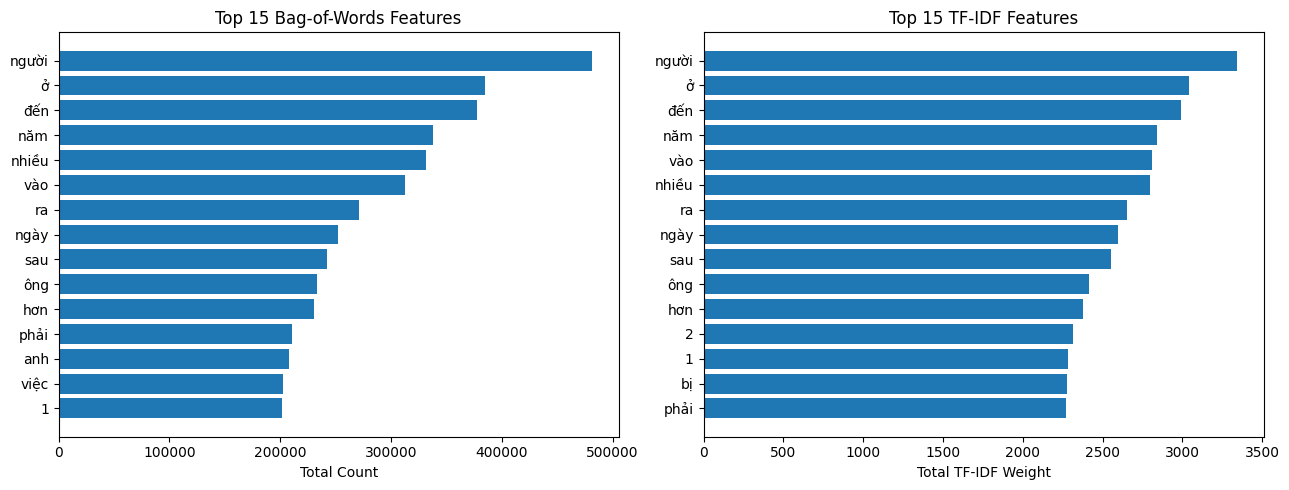

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].barh(bow_top["feature"][::-1], bow_top["score"][::-1])
axes[0].set_title("Top 15 Bag-of-Words Features")
axes[0].set_xlabel("Total Count")

axes[1].barh(tfidf_top["feature"][::-1], tfidf_top["score"][::-1])
axes[1].set_title("Top 15 TF-IDF Features")
axes[1].set_xlabel("Total TF-IDF Weight")

plt.tight_layout()
plt.show()

## 5. Conclusion

- **Bag of Words** đơn giản, dễ diễn giải nhưng không giữ thứ tự từ.
- **Word N-grams** bổ sung ngữ cảnh cục bộ nhưng làm vocabulary tăng nhanh.
- **TF-IDF** làm giảm ảnh hưởng của từ phổ biến và phù hợp làm đầu vào cho nhiều mô hình phân loại/tìm kiếm văn bản.
- **Feature Hashing** có số chiều cố định, không cần lưu vocabulary và phù hợp với dữ liệu lớn, nhưng khó diễn giải và có khả năng collision.